In [1]:
import os
import sys
import re
import math
import json
import pickle
import random
import numpy as np
from openai import OpenAI
import matplotlib.pyplot as plt
from collections import Counter
from anthropic import Anthropic
from dotenv import load_dotenv
from huggingface_hub import login


In [2]:
load_dotenv(override=True)
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')


In [3]:
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
from src import items
from src.tester import Tester

sys.modules['items'] = items
from src.items import Item

In [5]:
openai = OpenAI()
claude = Anthropic()

In [6]:
with open('data/train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('data/test.pkl', 'rb') as file:
    test = pickle.load(file)

In [7]:
def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [8]:
messages_for(test[0])


[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': "How much does this cost?\n\nDisney Animators' Littles Rapunzel Surprise Feature Playset - Tangled\nTowering new heights of fairytale fun are to be had with this Surprise Feature Playset, inspired by Tangled. Part of the Disney Animators' Collection, the adorable playset features Rapunzel, Pascal, a mystery figure, and more! Genuine, Original, Authentic Disney Store Pop-up playset includes nine pieces Pieces include Rapunzel, Pascal, painting, guitar, mirror, chair, and wardrobe Two figures act as keys to unlock music, lights, and sounds Rapunzel's tower features a highly detailed exterior, light-up window, and top carry handle Dimensions 9 x 7 x 4 inches, Weight 1.04 pounds, Manufacturer recommended age 3 years and"},
 {'role': 'assistant', 'content': 'Price is $'}]

In [9]:
def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [10]:
def gpt_4o_mini(item):
    response = openai.chat.completions.create(
        model="gpt-4o-mini", 
        messages=messages_for(item),
        seed=42,
        max_tokens=5
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [11]:
test[0].price

48.95

1: Guess: $49.99 Truth: $48.95 Error: $1.04 SLE: 0.00 Item: Disney Animators' Littles Rapunzel Surpr...
2: Guess: $10.99 Truth: $9.99 Error: $1.00 SLE: 0.01 Item: TIKROUND Youngtown Movement for Clock Re...
3: Guess: $349.99 Truth: $167.98 Error: $182.01 SLE: 0.53 Item: ARIES 205045 3-Inch Round Black Steel Ne...
4: Guess: $29.99 Truth: $166.08 Error: $136.09 SLE: 2.84 Item: Filterbuy 16x22x5 Air Filter MERV 13 Opt...
5: Guess: $45.00 Truth: $44.30 Error: $0.70 SLE: 0.00 Item: THE NORTH FACE Women's Etip¿ Gloves
6: Guess: $129.99 Truth: $299.99 Error: $170.00 SLE: 0.69 Item: Parrot Uncle Ceiling Fans with Lights an...
7: Guess: $9.99 Truth: $6.39 Error: $3.60 SLE: 0.16 Item: 50Pcs Aesthetic Stickers for Water Bottl...
8: Guess: $649.00 Truth: $639.95 Error: $9.05 SLE: 0.00 Item: Tamron B028N 18-400 mm f3.5-6.3 Di II VC...
9: Guess: $849.99 Truth: $530.00 Error: $319.99 SLE: 0.22 Item: Freedom OffRoad Uni-Ball Front Upper Con...
10: Guess: $49.99 Truth: $59.95 Error: $9.96 SLE: 0.03 Ite

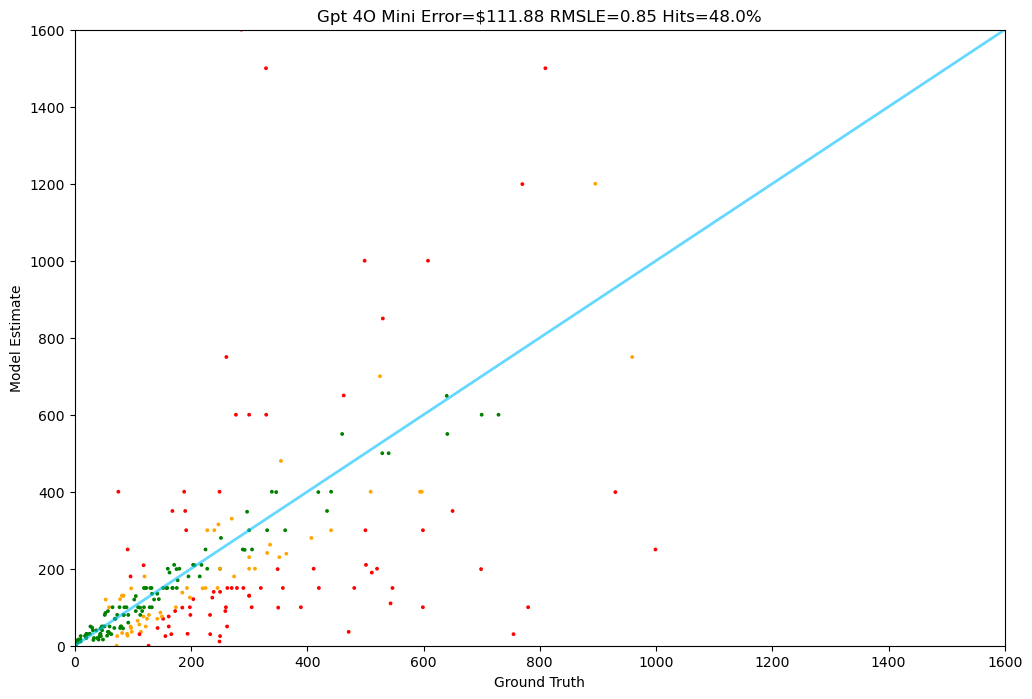

In [12]:
Tester.test(gpt_4o_mini, test)

In [13]:
def gpt_4o_frontier(item):
    response = openai.chat.completions.create(
        model="gpt-4o", 
        messages=messages_for(item),
        seed=42,
        max_tokens=5
    )
    reply = response.choices[0].message.content
    return get_price(reply)

1: Guess: $29.99 Truth: $48.95 Error: $18.96 SLE: 0.23 Item: Disney Animators' Littles Rapunzel Surpr...
2: Guess: $5.00 Truth: $9.99 Error: $4.99 SLE: 0.37 Item: TIKROUND Youngtown Movement for Clock Re...
3: Guess: $150.00 Truth: $167.98 Error: $17.98 SLE: 0.01 Item: ARIES 205045 3-Inch Round Black Steel Ne...
4: Guess: $80.00 Truth: $166.08 Error: $86.08 SLE: 0.52 Item: Filterbuy 16x22x5 Air Filter MERV 13 Opt...
5: Guess: $32.00 Truth: $44.30 Error: $12.30 SLE: 0.10 Item: THE NORTH FACE Women's Etip¿ Gloves
6: Guess: $180.99 Truth: $299.99 Error: $119.00 SLE: 0.25 Item: Parrot Uncle Ceiling Fans with Lights an...
7: Guess: $5.99 Truth: $6.39 Error: $0.40 SLE: 0.00 Item: 50Pcs Aesthetic Stickers for Water Bottl...
8: Guess: $699.00 Truth: $639.95 Error: $59.05 SLE: 0.01 Item: Tamron B028N 18-400 mm f3.5-6.3 Di II VC...
9: Guess: $400.00 Truth: $530.00 Error: $130.00 SLE: 0.08 Item: Freedom OffRoad Uni-Ball Front Upper Con...
10: Guess: $49.99 Truth: $59.95 Error: $9.96 SLE: 0.03 Ite

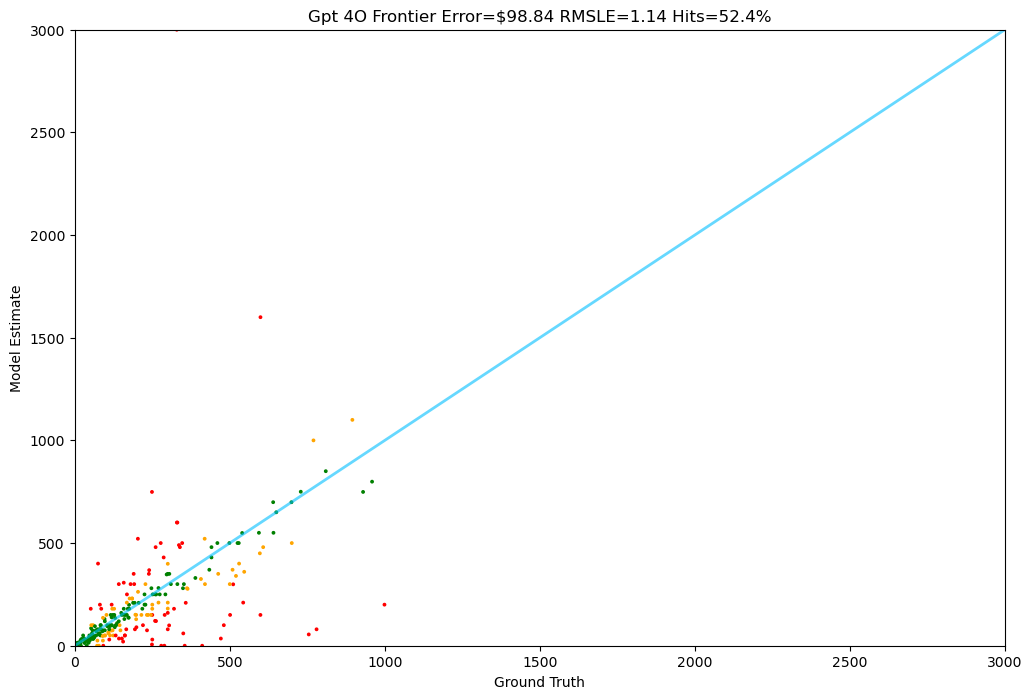

In [14]:
Tester.test(gpt_4o_frontier, test)

In [ ]:
def claude_haiku4_5(item):
    messages = messages_for(item)
    system_message = messages[0]['content']
    messages = messages[1:]
    response = claude.messages.create(
        model="claude-haiku-4-5",
        max_tokens=5,
        system=system_message,
        messages=messages
    )
    reply = response.content[0].text
    return get_price(reply)

1: Guess: $49.99 Truth: $48.95 Error: $1.04 SLE: 0.00 Item: Disney Animators' Littles Rapunzel Surpr...
2: Guess: $3.99 Truth: $9.99 Error: $6.00 SLE: 0.62 Item: TIKROUND Youngtown Movement for Clock Re...
3: Guess: $299.99 Truth: $167.98 Error: $132.01 SLE: 0.33 Item: ARIES 205045 3-Inch Round Black Steel Ne...
4: Guess: $29.99 Truth: $166.08 Error: $136.09 SLE: 2.84 Item: Filterbuy 16x22x5 Air Filter MERV 13 Opt...
5: Guess: $45.00 Truth: $44.30 Error: $0.70 SLE: 0.00 Item: THE NORTH FACE Women's Etip¿ Gloves
6: Guess: $89.99 Truth: $299.99 Error: $210.00 SLE: 1.43 Item: Parrot Uncle Ceiling Fans with Lights an...
7: Guess: $6.99 Truth: $6.39 Error: $0.60 SLE: 0.01 Item: 50Pcs Aesthetic Stickers for Water Bottl...
8: Guess: $349.00 Truth: $639.95 Error: $290.95 SLE: 0.37 Item: Tamron B028N 18-400 mm f3.5-6.3 Di II VC...
9: Guess: $349.99 Truth: $530.00 Error: $180.01 SLE: 0.17 Item: Freedom OffRoad Uni-Ball Front Upper Con...
10: Guess: $35.00 Truth: $59.95 Error: $24.95 SLE: 0.28 It

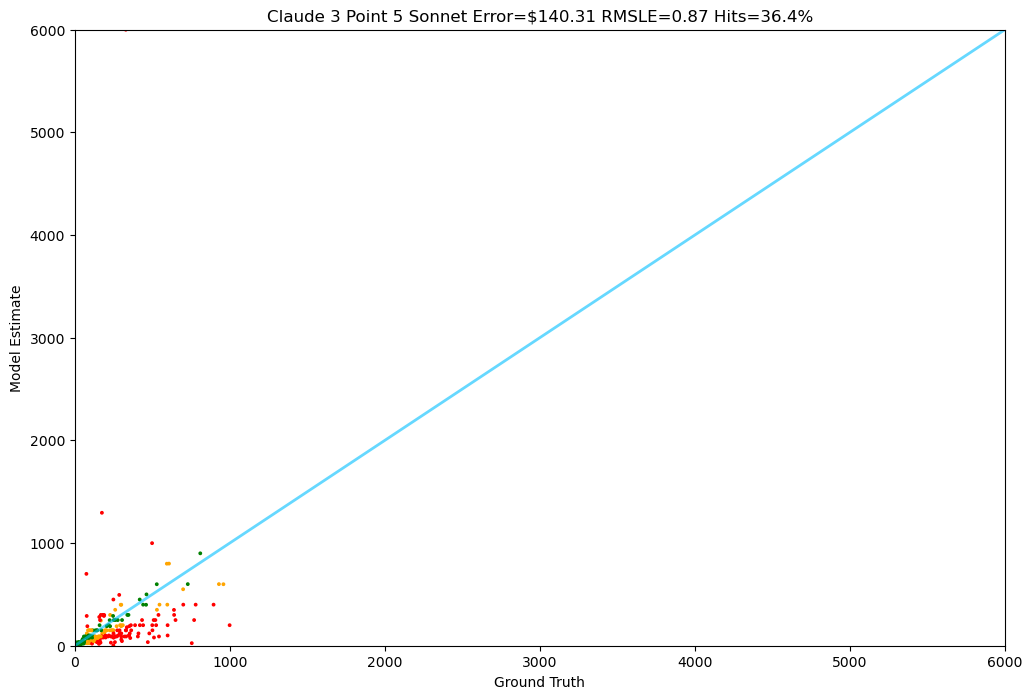

In [ ]:
Tester.test(claude_haiku4_5, test)


### LLM Models Performance Summary

The following table ranks the performance of the models run on the `test.pkl` data, from the most successful (lowest error) to the least successful.

| Model | Average Error (Pricer Error) | RMSLE | Hits (%) |
| :--- | :--- | :--- | :--- |
| **GPT 4O** | **$98.84** | **1.14** | **%52.4** |
| GPT 4O Mini | $111.88 | 0.85 | %48 |
| Claude Haiku 4.5 | $140.31 | 0.87 | %36.4 |
